In [1]:
%pip install -q --upgrade "datasets==2.21.0" "fsspec==2024.6.1"

In [1]:
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech

processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
model = SpeechT5ForTextToSpeech.from_pretrained("microsoft/speecht5_tts")

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SpeechT5ForTextToSpeech LOAD REPORT from: microsoft/speecht5_tts
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
speecht5.decoder.prenet.encode_positions.pe | UNEXPECTED |  | 
speecht5.encoder.prenet.encode_positions.pe | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
text = "Hello, how are you doing today?"
inputs = processor(text=text, return_tensors="pt", padding=True)

In [3]:
from datasets import load_dataset
import torch

embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
speaker_embeddings = torch.tensor(embeddings_dataset[7000]["xvector"]).unsqueeze(0)

In [4]:
speaker_embeddings.shape

torch.Size([1, 512])

In [5]:
spectrogram = model.generate_speech(inputs["input_ids"], speaker_embeddings)

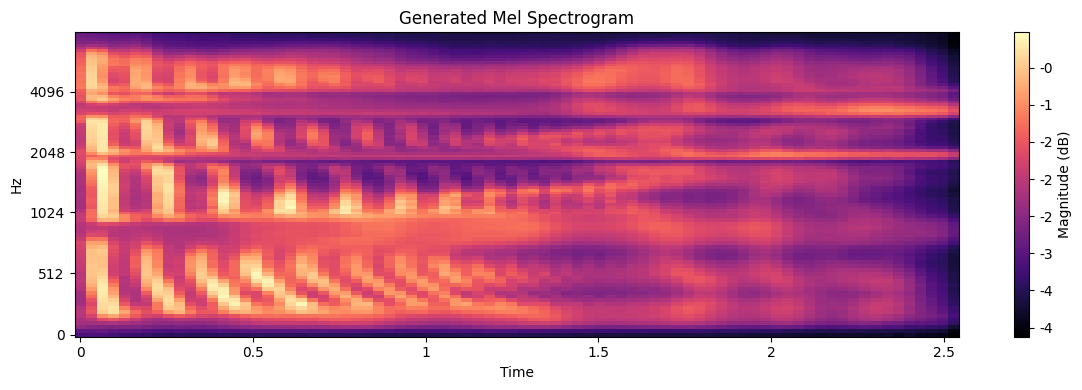

In [7]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12, 4))
librosa.display.specshow(
    spectrogram.numpy(),
    sr=16000,  # 采样率
    x_axis="time",
    y_axis="mel",
)
plt.colorbar(label="Magnitude (dB)", format="%+2.0f")
plt.title("Generated Mel Spectrogram")
plt.tight_layout()
plt.show()

In [24]:
from transformers import SpeechT5HifiGan

vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")

Loading weights:   0%|          | 0/158 [00:00<?, ?it/s]

In [28]:
speech = model.generate_speech(inputs["input_ids"], speaker_embeddings, vocoder=vocoder)

In [29]:
from IPython.display import Audio

Audio(speech.numpy(), rate=16000)